In [6]:
import app
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import rasterio
import rasterio.plot as rplt
import rasterio.windows  as rw
from rasterio.transform import Affine
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np
import cmocean as cmo
from matplotlib.patches import Rectangle

app.setup_logger(use_console_handler=False, use_file_handler=True)

import logging
logger = logging.getLogger(__name__)
logger.setLevel("INFO")

In [7]:
base_directory = r"D:\PhD\21_Experiments\TidesDamageDriver"
drainages_folder = os.path.join(
    base_directory, "02_processed", "02_drainages"
)
lima_folder = os.path.join(
    base_directory, "01_raw", "LIMA"
)
data_plot_folder = os.path.join(
    base_directory, "02_processed", "LIMA_plots"
)

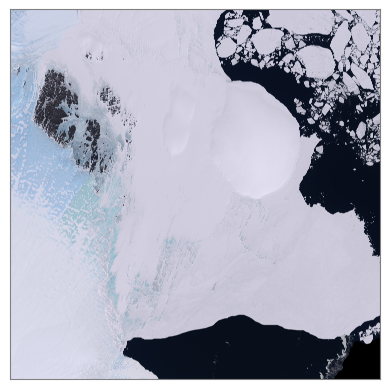

In [14]:
folders = os.listdir(lima_folder)

fig, ax = plt.subplots()
ax.spines["bottom"].set_color("gray")
ax.spines["top"].set_color("gray")
ax.spines["left"].set_color("gray")
ax.spines["right"].set_color("gray")
ax.tick_params(
    axis="both",  # changes apply to the x-axis
    which="both",  # both major and minor ticks are affected
    bottom=False,  # ticks along the bottom edge are off
    top=False,  # ticks along the top edge are off
    left=False,
    right=False,
    labelbottom=False,
    labelleft=False,
)
# Set the colormap
for ifolder, folder in enumerate(folders):
    files = [f for f in os.listdir(os.path.join(lima_folder, folder)) if f.endswith(".tif")]
    if len(files) == 0:
        continue
    with rasterio.open(os.path.join(lima_folder, folder, files[0])) as src:
        transform = src.transform
        bounds = src.bounds
        rplt.show(src, transform = transform, ax=ax)
    # # Add bounding box
    # rect = Rectangle(
    #     (bounds.left, bounds.bottom),
    #     bounds.right - bounds.left,
    #     bounds.top - bounds.bottom,
    #     linewidth=0.5,
    #     edgecolor='red',
    #     facecolor='none'
    # )
    # ax.add_patch(rect)
    # ax.text(
    #     bounds.left + 0.5 * (bounds.right - bounds.left),
    #     bounds.top - 0.5 * (bounds.top - bounds.bottom),
    #     folder,
    #     fontsize=8,
    #     color="red",
    #     ha ='center',
    #     va ='center',
    # )
    

    if ifolder == 2:
        break

In [ ]:
import os
import matplotlib.pyplot as plt
import rasterio
import rasterio.plot as rplt

folders = os.listdir(lima_folder)

fig, ax = plt.subplots(figsize=(12, 12))
ax.spines["bottom"].set_color("gray")
ax.spines["top"].set_color("gray")
ax.spines["left"].set_color("gray")
ax.spines["right"].set_color("gray")
ax.tick_params(
    axis="both",
    which="both",
    bottom=False,
    top=False,
    left=False,
    right=False,
    labelbottom=False,
    labelleft=False,
)

# Optional: Track total bounds to fix axis
global_bounds = []

for ifolder, folder in enumerate(folders):
    files = [f for f in os.listdir(os.path.join(lima_folder, folder)) if f.endswith(".tif")]
    if not files:
        continue

    fpath = os.path.join(lima_folder, folder, files[0])
    with rasterio.open(fpath) as src:
        rplt.show(src, ax=ax, adjust='linear')  # Plot in-place without modifying extent
        bounds = src.bounds
        global_bounds.append(bounds)

    # Optional: label center of tile
    ax.text(
        (bounds.left + bounds.right) / 2,
        (bounds.top + bounds.bottom) / 2,
        folder,
        fontsize=8,
        color="red",
        ha='center',
        va='center',
    )

    # Optional: break early for testing
    # if ifolder == 2:
    #     break

# Optional: Set total bounding box if needed
if global_bounds:
    minx = min(b.left for b in global_bounds)
    maxx = max(b.right for b in global_bounds)
    miny = min(b.bottom for b in global_bounds)
    maxy = max(b.top for b in global_bounds)
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

plt.show()



KeyboardInterrupt: 